In [1]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
import tqdm
%matplotlib inline
from IPython.display import clear_output
from typing import List, Tuple, Optional
import matplotlib.ticker as mticker

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_time_folder = "drive/MyDrive/mestrado_final_files/models/SpentTimeModel_ExtraInfo_State/"
# models_token_metrics_folder = "drive/MyDrive/mestrado_final_files/metrics_models/NGramModel_ExtraInfo_State/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel_ExtraInfo_State\\"
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo_State\\"

#models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
def get_vectorized_murphy(y_true_multiclasse, y_prob_matriz, top_n=600, n_bins=10):
    """
    Calcula as métricas de Murphy de forma vetorizada, corrigindo o
    shape de arrays dinâmicos e espelhando a discretização exata do pd.cut.
    """
    N_amostras = len(y_true_multiclasse)
    if N_amostras == 0:
        return pd.DataFrame()

    # 1. Identificar Top Tokens presentes estritamente neste slice
    tokens, counts = np.unique(y_true_multiclasse, return_counts=True)
    sort_idx = np.argsort(-counts)

    top_tokens_ids = tokens[sort_idx][:top_n]
    top_counts = counts[sort_idx][:top_n]

    # A CORREÇÃO CRÍTICA DO SHAPE:
    actual_n = len(top_tokens_ids)

    # 2. Isolar matrizes para os tokens filtrados
    P = y_prob_matriz[:, top_tokens_ids]
    Y = (y_true_multiclasse[:, None] == top_tokens_ids).astype(float)

    # 3. Taxas Base e Incerteza
    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    # 4. Discretização exata equivalente ao pd.cut(include_lowest=True)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    # digitize com right=True aloca valores <= à borda direita do bin
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    # Vetores dimensionados corretamente para o slice atual
    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = (bins == b) # booleano (N_amostras, actual_n)
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        # np.where é mais seguro e direto que multiplicar float por bool
        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        true_fraction = np.zeros(actual_n)
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras
        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid])**2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid])**2

    brier_score = reliability - resolution + uncertainty

    return pd.DataFrame({
        'token_id': top_tokens_ids,
        'frequencia': top_counts,
        'brier_score_multinomial': brier_score,
        'reliability_erro': reliability,
        'resolution_poder': resolution,
        'uncertainty_caos': uncertainty
    })

def get_vectorized_murphy_all_classes(y_true_multiclasse, y_prob_matriz, classes=None, n_bins=10):
    """
    Calcula a decomposição de Murphy considerando todas as classes possíveis.
    Isso evita perder reliability de classes não observadas no y_true do grupo,
    mas que receberam probabilidade positiva do modelo.
    """
    N_amostras = len(y_true_multiclasse)

    if N_amostras == 0:
        return pd.DataFrame()

    if classes is None:
        classes = np.arange(y_prob_matriz.shape[1])

    classes = np.asarray(classes)

    P = y_prob_matriz[:, classes]
    Y = (y_true_multiclasse[:, None] == classes).astype(float)

    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    actual_n = len(classes)

    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = bins == b
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        true_fraction = np.zeros(actual_n)

        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras

        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid]) ** 2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid]) ** 2

    brier_decomp = reliability - resolution + uncertainty

    frequencia = Y.sum(axis=0).astype(int)

    return pd.DataFrame({
        "token_id": classes,
        "frequencia": frequencia,
        "brier_score_multinomial": brier_decomp,
        "reliability_erro": reliability,
        "resolution_poder": resolution,
        "uncertainty_caos": uncertainty
    })

In [11]:
with open(data_folder + 'data_time_features.pkl', 'rb') as f:
    df_time_features = pickle.load(f)

In [2]:
%run 01_functions_training.ipynb
#%run drive/MyDrive/mestrado_final_files/notebooks/01_functions_training.ipynb

In [13]:
with open(data_folder + 'dict_set_covariables.pkl', 'rb') as f:
    dict_set_covariables = pickle.load(f)

In [3]:
list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_" in item and ".pth" in item]

In [15]:
VOCAB_SIZE = 601
TIME_SIZE = 301
STATE_EMBEDDING_DIM = 16
STATE_SIZE = 225


In [16]:
def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

def multiclass_cross_entropy(y_true, y_prob, eps=1e-15):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(np.log(y_prob[np.arange(len(y_true)), y_true]))

def process_group(idx, dev_y, all_probs, classes = None, get_bs_global = False, get_ce = False, get_mae = False):
    y_true_sub = dev_y[idx]
    y_prob_sub = all_probs[idx]

    if classes is None:
        classes = np.arange(y_prob_sub.shape[1])

    df_res = get_vectorized_murphy_all_classes(y_true_multiclasse=y_true_sub, y_prob_matriz = y_prob_sub, classes = classes, n_bins = 10)

    if get_bs_global:
        bs_global = multiclass_brier_score(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["brier_score_multinomial"] = bs_global

    if get_ce:
        ce_global = multiclass_cross_entropy(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["cross_entropy"] = ce_global

    if get_mae:
        expected_output = y_prob_sub @ np.arange(y_prob_sub.shape[1])
        mae_global = np.mean(np.abs(y_true_sub - expected_output))
        df_res["mae"] = mae_global

    return df_res

def multiclass_brier_score(y_true, y_prob):
    """
    Calcula o Brier Score Global para classificação multiclasse.

    y_true: array 1D com os índices reais dos tokens, shape (N,)
    y_prob: array 2D com as probabilidades preditas (softmax), shape (N, C)
    """
    N_amostras, n_classes = y_prob.shape

    # Cria a representação one-hot dos alvos (0.0 para erro, 1.0 para acerto)
    y_true_one_hot = np.zeros_like(y_prob, dtype=float)
    y_true_one_hot[np.arange(N_amostras), y_true] = 1.0

    # Calcula o erro quadrático, soma por classe e tira a média por amostra
    brier_score = np.mean(np.sum((y_prob - y_true_one_hot)**2, axis=1))

    return brier_score

In [17]:
def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"


In [ ]:
list_decomposition_time = []
list_decomposition_dif = []
list_decomposition_time_dif = []
list_decomposition_season = []

group_variables1 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables2 = ["cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables3 = ["period", "cat_time", "cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables4 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel" in item and ".pth" in item and str_season in item]

    # 1. PREPARAÇÃO DOS DADOS DA TEMPORADA (FORA DO LOOP DE MODELOS)
    df_ = df_time_features.query("season == @season").query("season_split == 'dev'")

    # Processamento temporal feito uma única vez por temporada
    df_ = (df_
           .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))
           .pipe(get_match_splits, num_secs = 200))\
    .assign(cat_time = lambda df: df["cat_time"].astype("str"))\
    .assign(cat_dif = lambda df: df["token_state"] % 9)

    # Conversão eficiente de memória
    dev_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
    dev_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    dev_stt = torch.from_numpy(np.asarray(df_["token_state"].to_list())).to(torch.int64)
    dev_y = df_["target_time"].values
    dev_mask = torch.tensor(build_logit_mask_spent_time_models(df_), dtype = torch.bool, device = device)

    print(season)
    for model_filename in tqdm.tqdm(list_models):

        CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
        EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
        variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
        numerical_input_size = len(dict_set_covariables['index'][variables_config])
        num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
        num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
        dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
        layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

        index_covariables = dict_set_covariables["index"][variables_config]

        time_model = SpentTimeModel_ExtraInfo_State(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                                    embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = numerical_input_size,
                                                    state_vocab_size = STATE_SIZE, state_embedding_dim = STATE_EMBEDDING_DIM,
                                                    num_hidden_neurons = num_hidden_neurons, num_layers = num_layers,
                                                    activation_function = nn.GELU, dropout_rate = dropout_rate, use_layer_norm = layer_norm)

        time_model.load_state_dict(torch.load(models_time_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
        time_model.eval()

        # 2. INFERÊNCIA
        with torch.no_grad():
            # Ajuste condicional para modelos que requerem variáveis numéricas
            output_model = time_model(dev_tkn[:, -CONTEXT_SIZE:], dev_num[:, index_covariables], dev_stt)
            output_model = output_model.masked_fill(dev_mask, -1e9)
            all_probs = torch.softmax(output_model, dim = 1).cpu().numpy()

        # 3. EXTRAÇÃO POR TEMPO
        results_time = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            results_time.append(res_df)

        df_decomposition_by_time = pd.concat(results_time, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time = df_decomposition_by_time\
        .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time.append(df_resultados_time)

        results_dif = []
        for name, group_idx in df_.groupby(["season_split", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["cat_dif"] = name[1]
            results_dif.append(res_df)

        df_decomposition_by_dif = pd.concat(results_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_dif = df_decomposition_by_dif\
        .groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_dif[group_variables2 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_dif.append(df_resultados_dif)

        # 3. EXTRAÇÃO POR TIME E DIF
        results_time_dif = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            res_df["cat_dif"] = name[3]
            results_time_dif.append(res_df)

        df_decomposition_by_time_dif = pd.concat(results_time_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time_dif = df_decomposition_by_time_dif\
        .groupby(group_variables3 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time_dif[group_variables3 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time_dif.append(df_resultados_time_dif)

        # 4. EXTRAÇÃO POR SPLIT
        results_split = []
        for name, group_idx in df_.groupby(["season_split"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
            res_df["season_split"] = name
            results_split.append(res_df)

        df_decomposition_by_split = pd.concat(results_split, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_split = df_decomposition_by_split\
        .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_split[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_season.append(df_resultados_split)


2018-19


100%|██████████| 32/32 [06:48<00:00, 12.76s/it]


2019-20


100%|██████████| 32/32 [06:14<00:00, 11.71s/it]


2020-21


100%|██████████| 32/32 [05:56<00:00, 11.14s/it]


2021-22


 38%|███▊      | 12/32 [02:32<04:10, 12.52s/it]

In [ ]:
df_murphy_decomposition_by_time = pd.concat(list_decomposition_time, ignore_index = True)
df_murphy_decomposition_by_time.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TIME_MODEL.parquet", index = False, compression = "zstd")

In [ ]:
df_murphy_decomposition_by_dif = pd.concat(list_decomposition_dif, ignore_index = True)
df_murphy_decomposition_by_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_dif_TIME_MODEL.parquet", index = False, compression = "zstd")

In [ ]:
df_murphy_decomposition_by_time_dif = pd.concat(list_decomposition_time_dif, ignore_index = True)
df_murphy_decomposition_by_time_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_dif_TIME_MODEL.parquet", index = False, compression = "zstd")

In [ ]:
df_murphy_decomposition_by_season_split = pd.concat(list_decomposition_season, ignore_index = True)
df_murphy_decomposition_by_season_split.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TIME_MODEL.parquet", index = False, compression = "zstd")


In [ ]:
list_num_parametros = []
for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_ExtraInfo_State" in item and ".pkl" in item and str_season in item]

    for file in tqdm.tqdm(list_models):
        with open(models_time_folder + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros.append((file.replace("results_", ""), resultados_modelo["num_parameters"]))



  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [00:00<00:00, 105.59it/s]


In [ ]:
df_parameters = pd.DataFrame(list_num_parametros, columns = ["modelname", "num_parameters"])

In [ ]:
df_parameters\
.assign(seasondata = lambda df: df["modelname"].str.split("_").str[3].str.replace("seasondata", "").astype("int"))\
.assign(context_size = lambda df: df["modelname"].str.split("_").str[4].str.replace("context", "").astype("int"))\
.assign(embedding_layer_size = lambda df: df["modelname"].str.split("_").str[5].str.replace("embedding", "").astype("int"))\
.assign(num_layers = lambda df: df["modelname"].str.split("_").str[6].str.replace("numlayers", "").astype("int"))\
.assign(num_hidden_neurons = lambda df: df["modelname"].str.split("_").str[7].str.replace("numneurons", "").astype("int"))\
.assign(dropout_rate = lambda df: df["modelname"].str.split("_").str[8].str.replace("dropout", "").replace("no", 0).astype("int") / 10)\
.assign(layer_norm = lambda df: df["modelname"].str.split("_").str[9].str.replace("layernorm", ""))\
.assign(set_covariables = lambda df: df["modelname"].str.split("_").str[10].str.replace("setcovariables", "").replace("\.pkl", "", regex = True).astype("int"))\
.drop(columns = "modelname")\
.sort_values("num_parameters")\
.drop_duplicates(["context_size", "embedding_layer_size", "num_layers", "num_hidden_neurons", "layer_norm", "set_covariables"])\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "set_covariables"], columns = ["num_layers", "layer_norm"], values = "num_parameters", aggfunc= lambda x: x)\
.reset_index()

num_layers context_size embedding_layer_size num_hidden_neurons  \
layer_norm                                                        
0                     5                   32                 50   
1                     5                   32                 50   
2                     5                   64                 50   
3                     5                   64                 50   

num_layers set_covariables      3             5         
layer_norm                  False   True  False   True  
0                        1  52933  53517  58033  58817  
1                        2  54133  54765  59233  60065  
2                        1  80165  81069  85265  86369  
3                        2  81365  82317  86465  87617

In [ ]:
os.listdir(models_token_metrics_folder)

['murphy_decomposition_by_time.parquet',
 'murphy_decomposition_by_season_split.parquet',
 'murphy_decomposition_by_time_TIME_MODEL.parquet',
 'murphy_decomposition_by_season_split_TIME_MODEL.parquet',
 'murphy_decomposition_by_time',
 'murphy_decomposition_by_season_split']

In [ ]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TIME_MODEL.parquet")

In [ ]:
group_variables1 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [ ]:
df_resultados1 = df_murphy_decomposition_by_season_split\
.groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_season_split[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

df_resultados2 = df_resultados1\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [ ]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  2.3709 (0.0219) [3]  2.3773 (0.0231) [14]   
1                          2  2.3698 (0.0222) [1]   2.3756 (0.0219) [9]   
2                          1  2.3710 (0.0200) [4]  2.3764 (0.0220) [11]   
3                          2  2.3704 (0.0214) [2]  2.3759 (0.0213) [10]   
4                          1  2.3722 (0.0207) [6]  2.3792 (0.0206) [21]   
5                          2  2.3710 (0.0220) [5]  2.3790 (0.0216) [20]   
6                          1  2.3735 (0.0201) [7]  2.3785 (0.0208) [19]   
7                          2  2.3753 (0.0204) [8]  2.3770 (0.0212) [13]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.3801 (0.0213) [23]  2.3802 (0.0228) [24]  
1             2.3775 (0.0212) [17]  2.3773 (0.0224) [15]  
2             2.3940 (0.0194) [32]  2.3929 (0.0211) [28]  
3             2.3929 (0.0211) [29]  2.3906 (0.0232) [26]  
4             2.3775 (0.0217) [16]  2.3795 (0.0234) [22]  
5             2.3775 (0.0212) [18]  2.3768 (0.0224) [12]  
6             2.3932 (0.0192) [30]  2.3936 (0.0195) [31]  
7             2.3920 (0.0209) [27]  2.3893 (0.0208) [25]

In [ ]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  0.1621 (0.0044) [4]  0.1610 (0.0047) [16]   
1                          2  0.1622 (0.0046) [3]  0.1611 (0.0043) [10]   
2                          1  0.1626 (0.0040) [2]  0.1611 (0.0045) [13]   
3                          2  0.1627 (0.0043) [1]  0.1611 (0.0042) [11]   
4                          1  0.1619 (0.0040) [5]  0.1604 (0.0040) [24]   
5                          2  0.1618 (0.0044) [7]  0.1605 (0.0046) [22]   
6                          1  0.1618 (0.0041) [6]  0.1608 (0.0043) [20]   
7                          2  0.1612 (0.0040) [9]  0.1610 (0.0040) [17]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.1605 (0.0041) [23]  0.1607 (0.0044) [21]  
1             0.1608 (0.0040) [19]  0.1611 (0.0042) [12]  
2             0.1583 (0.0036) [31]  0.1592 (0.0040) [28]  
3             0.1582 (0.0041) [32]  0.1594 (0.0044) [26]  
4             0.1610 (0.0042) [15]  0.1609 (0.0045) [18]  
5             0.1610 (0.0041) [14]   0.1613 (0.0045) [8]  
6             0.1583 (0.0036) [30]  0.1592 (0.0039) [27]  
7             0.1584 (0.0043) [29]  0.1598 (0.0043) [25]

In [ ]:
df_resultados2\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1  24.348 (0.3430) [13]  24.387 (0.3031) [18]   
1                          2   24.306 (0.3841) [5]   24.318 (0.3124) [7]   
2                          1   24.316 (0.3189) [6]  24.426 (0.4407) [21]   
3                          2   24.285 (0.3380) [2]   24.338 (0.3206) [9]   
4                          1  24.341 (0.3238) [11]  24.343 (0.3572) [12]   
5                          2   24.287 (0.3387) [3]  24.439 (0.4295) [22]   
6                          1  24.371 (0.3103) [17]  24.360 (0.3028) [15]   
7                          2  24.341 (0.3050) [10]  24.362 (0.4063) [16]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             24.530 (0.3391) [28]  24.353 (0.3259) [14]  
1             24.459 (0.3545) [24]   24.296 (0.3453) [4]  
2             24.613 (0.3215) [30]  24.517 (0.3268) [27]  
3             24.615 (0.3648) [31]  24.419 (0.3707) [20]  
4             24.463 (0.3444) [25]   24.337 (0.3629) [8]  
5             24.455 (0.3190) [23]   24.244 (0.3764) [1]  
6             24.616 (0.3121) [32]  24.467 (0.3004) [26]  
7             24.599 (0.3204) [29]  24.399 (0.2975) [19]

In [ ]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["layer_norm", "dropout_rate"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	16.0	15.5	10.417933	1.0	 7.75	14.5	24.50	32.0
# 1	64	16.0	17.5	 8.438009	5.0	11.00	18.5	22.75	31.0

# num_layers
# 0	3	16.0	14.125	 7.410578	1.0	8.25	15.5	20.25	24.0
# 1	5	16.0	18.875	10.719919	2.0	9.50	22.0	28.25	32.0

# set_covariables
# 0	1	16.0	18.1875	9.833404	3.0	10.00	20.0	25.00	32.0
# 1	2	16.0	14.8125	8.893584	1.0	 8.75	14.0	21.25	29.0

# dropout_rate
# 0	0.0	16.0	 9.5625	6.376715	 1.0	 4.75	 8.5	13.25	21.0
# 1	0.3	16.0	23.4375	6.207187	12.0	17.75	24.5	28.25	32.0

# layer_norm
# 0	False	16.0	14.25	11.096546	1.0	 4.75	12.0	24.00	32.0
# 1	True	16.0	18.75	 6.923390	9.0	12.75	19.5	24.25	31.0

# layer_norm, dropout_rate
# 0	False	0.0	8.0	 4.500	2.449490	 1.0	 2.75	 4.5	 6.25	8.0
# 1	False	0.3	8.0	24.000	6.369571	16.0	17.75	25.0	29.25	32.0
# 2	True	0.0	8.0	14.625	4.749060	 9.0	10.75	13.5	19.25	21.0
# 3	True	0.3	8.0	22.875	6.424006	12.0	20.25	24.5	26.50	31.0



,layer_norm,dropout_rate,count,mean,std,min,25%,50%,75%,max
0,False,0.0,8.0,4.500,2.449490,1.0,2.75,4.5,6.25,8.0
1,False,0.3,8.0,24.000,6.369571,16.0,17.75,25.0,29.25,32.0
2,True,0.0,8.0,14.625,4.749060,9.0,10.75,13.5,19.25,21.0
3,True,0.3,8.0,22.875,6.424006,12.0,20.25,24.5,26.50,31.0


In [ ]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["embedding_layer_size"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	16.0	15.75	10.414733	1.0	8.50	14.5	23.75	32.0
# 1	64	16.0	17.25	 8.497058	5.0	8.75	17.5	24.25	30.0

# num_layers
# 0	3	16.0	13.8125	 7.054254	3.0	 7.75	14.5	19.50	24.0
# 1	5	16.0	19.1875	10.802585	1.0	10.50	22.5	28.25	32.0

# set_covariables
# 0	1	16.0	17.6875	9.554885	2.0	11.25	19.0	24.75	31.0
# 1	2	16.0	15.3125	9.357484	1.0	 8.75	13.0	22.75	32.0

#dropout_rate
# 0	0.0	16.0	10.625	7.347335	1.0	 4.75	 9.5	16.25	24.0
# 1	0.3	16.0	22.375	7.365460	8.0	17.25	24.0	28.25	32.0

# layer_norm
# 0	False	16.0	14.375	11.406869	1.0	 4.75	11.5	24.50	32.0
# 1	True	16.0	18.625	 6.489735	8.0	12.75	19.0	24.25	28.0

# layer_norm, dropout_rate
# 0	False	0.0	8.0	4.625	2.669270	 1.0	 2.75	 4.5	 6.25	 9.0
# 1	False	0.3	8.0	24.125	7.376362	14.0	18.00	26.0	30.25	32.0
# 2	True	0.0	8.0	16.625	5.125218	10.0	12.50	16.5	20.50	24.0
# 3	True	0.3	8.0	20.625	7.405355	 8.0	16.50	23.0	26.25	28.0


,embedding_layer_size,count,mean,std,min,25%,50%,75%,max
0,32,16.0,15.75,10.414733,1.0,8.50,14.5,23.75,32.0
1,64,16.0,17.25,8.497058,5.0,8.75,17.5,24.25,30.0


In [ ]:
df_resultados1\
.pivot_table(index = group_variables1, columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,5,32,1,50,3,0.0,False,0.157570,0.161149,0.158682,0.164764,0.168342
1,5,32,1,50,3,0.0,True,0.156437,0.159927,0.157285,0.163679,0.167797
2,5,32,1,50,3,0.3,False,0.156142,0.159572,0.157804,0.162918,0.166398
3,5,32,1,50,3,0.3,True,0.156641,0.159163,0.157399,0.163599,0.167195
4,5,32,1,50,5,0.0,False,0.158232,0.161889,0.159635,0.165189,0.168140
5,5,32,1,50,5,0.0,True,0.156529,0.160007,0.157925,0.163463,0.167679
6,5,32,1,50,5,0.3,False,0.154682,0.157085,0.155948,0.160487,0.163501
7,5,32,1,50,5,0.3,True,0.155123,0.157542,0.156807,0.161551,0.165225
8,5,32,2,50,3,0.0,False,0.157438,0.162119,0.158316,0.164477,0.168673
9,5,32,2,50,3,0.0,True,0.156880,0.160531,0.157447,0.163850,0.167237


In [ ]:
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TIME_MODEL.parquet")

In [ ]:
group_variables2 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [ ]:
df_murphy_decomposition_by_time\
.groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()

,period,cat_time,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,seasondata,reliability_erro,resolution_poder,uncertainty_caos
0,1,0-200,5,32,1,50,3,0.0,False,201819,0.071065,0.447415,0.955873
1,1,0-200,5,32,1,50,3,0.0,False,201920,0.075961,0.440223,0.961413
2,1,0-200,5,32,1,50,3,0.0,False,202021,0.078639,0.437430,0.958808
3,1,0-200,5,32,1,50,3,0.0,False,202122,0.082443,0.468309,0.968627
4,1,0-200,5,32,1,50,3,0.0,False,202223,0.067692,0.471275,0.960279
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25435,5,800-1000,5,64,2,50,5,0.3,True,201819,0.091758,0.157713,0.929752
25436,5,800-1000,5,64,2,50,5,0.3,True,201920,0.087488,0.172731,0.928889
25437,5,800-1000,5,64,2,50,5,0.3,True,202021,0.149685,0.203333,0.840000
25438,5,800-1000,5,64,2,50,5,0.3,True,202122,0.224878,0.268873,0.877551


In [ ]:
df_resultados3 = df_murphy_decomposition_by_time\
.groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_time[group_variables2 + ["seasondata", "brier_score_multinomial", "cross_entropy", "mae"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

In [ ]:
df_resultados4 = df_resultados3\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

In [ ]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   1.7508 (0.0646) [6]  1.8338 (0.0611) [22]   
1                          2   1.7451 (0.0781) [4]  1.8392 (0.0600) [23]   
2                          1   1.7002 (0.0707) [1]  1.8327 (0.0707) [21]   
3                          2   1.7012 (0.0811) [2]  1.8181 (0.0568) [17]   
4                          1  1.7645 (0.0625) [16]  1.8479 (0.0790) [26]   
5                          2   1.7571 (0.0475) [9]  1.8523 (0.0699) [28]   
6                          1   1.7353 (0.0587) [3]  1.8321 (0.0603) [20]   
7                          2   1.7553 (0.0836) [7]  1.8585 (0.0713) [29]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             1.7634 (0.0502) [14]  1.8407 (0.0564) [25]  
1             1.7617 (0.0646) [12]  1.8392 (0.0501) [24]  
2              1.7559 (0.0620) [8]  1.8835 (0.0516) [32]  
3             1.7596 (0.0585) [11]  1.8747 (0.0703) [31]  
4              1.7507 (0.0465) [5]  1.8310 (0.0559) [19]  
5             1.7595 (0.0524) [10]  1.8191 (0.0510) [18]  
6             1.7644 (0.0572) [15]  1.8728 (0.0480) [30]  
7             1.7624 (0.0693) [13]  1.8519 (0.0775) [27]

In [ ]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1  0.4170 (0.0156) [11]  0.3799 (0.0127) [25]   
1                          2   0.4182 (0.0217) [9]  0.3788 (0.0122) [26]   
2                          1   0.4420 (0.0183) [2]  0.3818 (0.0136) [21]   
3                          2   0.4426 (0.0244) [1]  0.3858 (0.0103) [17]   
4                          1  0.4074 (0.0165) [16]  0.3749 (0.0135) [28]   
5                          2  0.4083 (0.0112) [15]  0.3752 (0.0166) [27]   
6                          1   0.4186 (0.0177) [8]  0.3808 (0.0131) [23]   
7                          2  0.4093 (0.0213) [14]  0.3745 (0.0128) [30]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.4172 (0.0146) [10]  0.3816 (0.0107) [22]  
1             0.4135 (0.0185) [13]  0.3820 (0.0107) [20]  
2              0.4260 (0.0189) [3]  0.3737 (0.0115) [32]  
3              0.4236 (0.0169) [4]  0.3747 (0.0154) [29]  
4              0.4213 (0.0118) [5]  0.3825 (0.0133) [19]  
5             0.4162 (0.0128) [12]  0.3855 (0.0094) [18]  
6              0.4211 (0.0151) [6]  0.3745 (0.0127) [31]  
7              0.4210 (0.0235) [7]  0.3802 (0.0168) [24]

In [ ]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  4.8370 (0.3179) [7]   4.9215 (0.3073) [9]   
1                          2  4.8012 (0.3242) [6]  5.1170 (0.3520) [17]   
2                          1  4.7234 (0.2414) [4]  5.0011 (0.3538) [11]   
3                          2  4.6760 (0.3350) [2]  5.0661 (0.3592) [13]   
4                          1  4.8803 (0.3443) [8]  4.9692 (0.4773) [10]   
5                          2  4.7942 (0.2944) [5]  5.1524 (0.3235) [20]   
6                          1  4.6575 (0.2395) [1]  5.0904 (0.2640) [15]   
7                          2  4.7128 (0.4051) [3]  5.1555 (0.4302) [21]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             5.3019 (0.2948) [29]  5.1103 (0.3022) [16]  
1             5.1815 (0.2505) [22]  5.1175 (0.3108) [18]  
2             5.2572 (0.3086) [27]  5.3752 (0.2539) [31]  
3             5.2166 (0.3839) [24]  5.2842 (0.3903) [28]  
4             5.2545 (0.2260) [26]  5.0887 (0.2256) [14]  
5             5.1462 (0.2996) [19]  5.0450 (0.1842) [12]  
6             5.3460 (0.3890) [30]  5.4077 (0.2928) [32]  
7             5.2079 (0.2713) [23]  5.2198 (0.3436) [25]

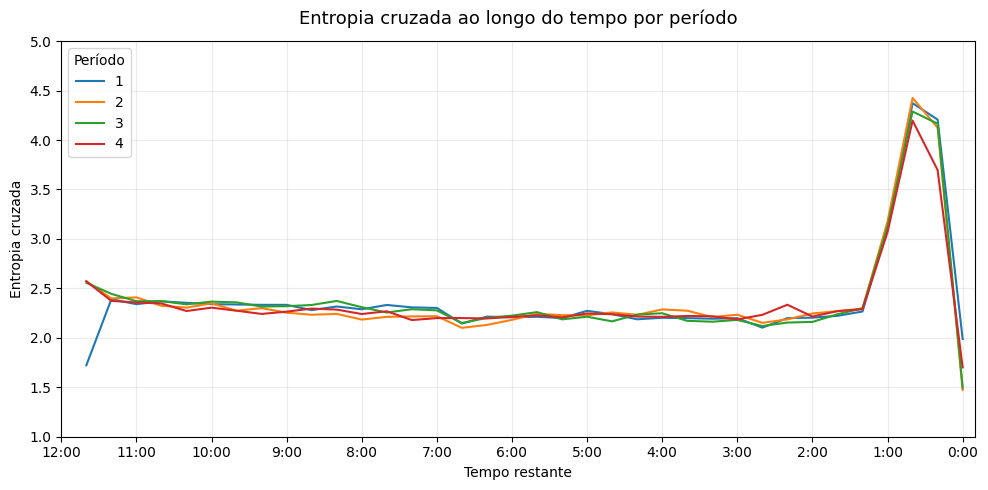

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "cross_entropy_mean")\
.plot(ax = ax)

ax.set_ylim(1, 5)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Entropia cruzada ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Entropia cruzada")
#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



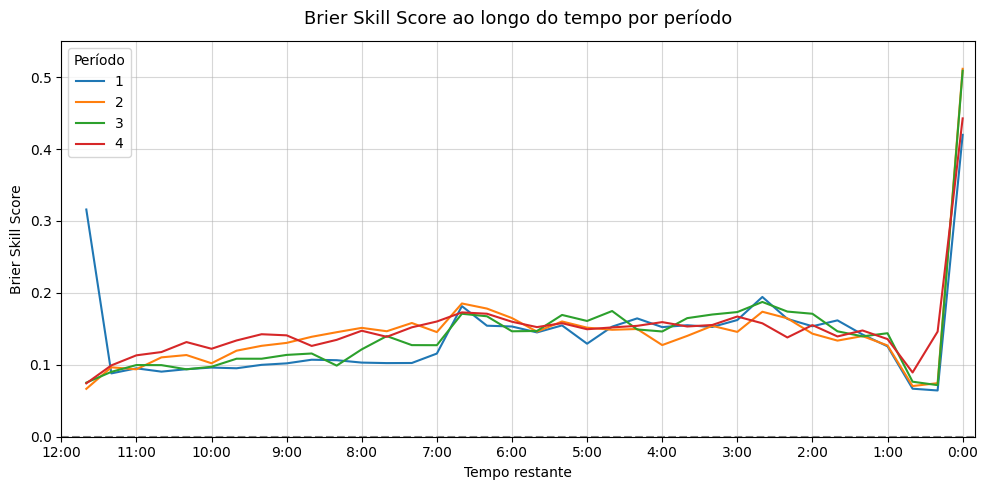

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bss_mean")\
.plot(ax = ax)

ax.set_ylim(0, 0.55)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.5)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Skill Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Skill Score")
ax.axhline(0, zorder = -3, linestyle = '--', color = 'gray')
plt.tight_layout()



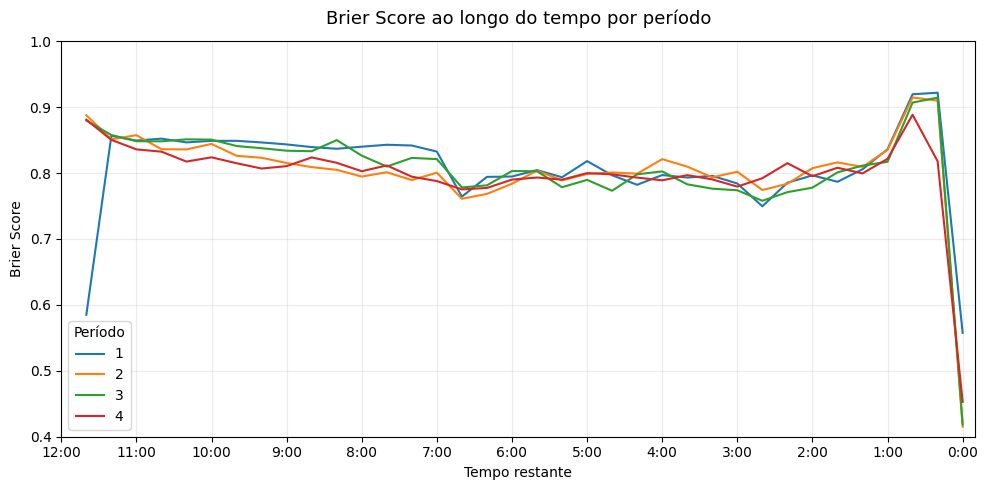

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bs_mean")\
.plot(ax = ax)

ax.set_ylim(0.4, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Score")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



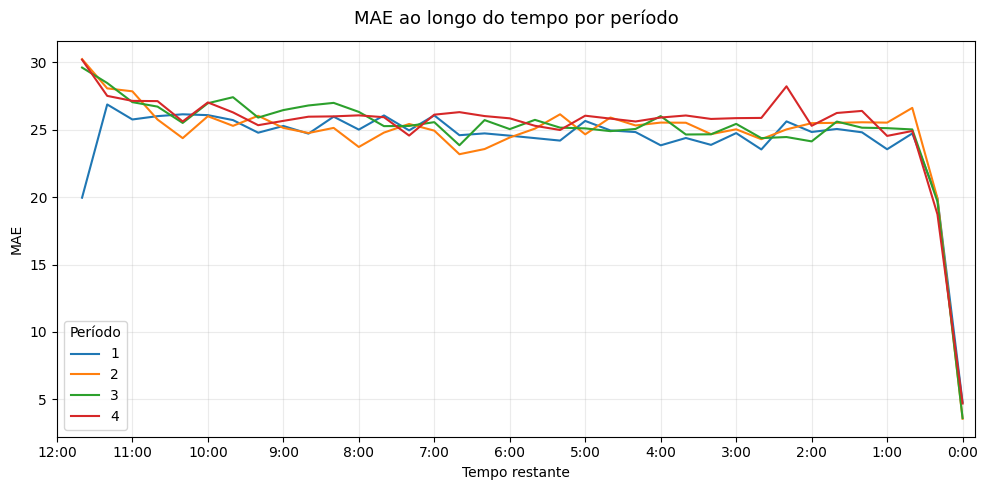

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "mae_mean")\
.plot(ax = ax)

#ax.set_ylim(0.4, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("MAE ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("MAE")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



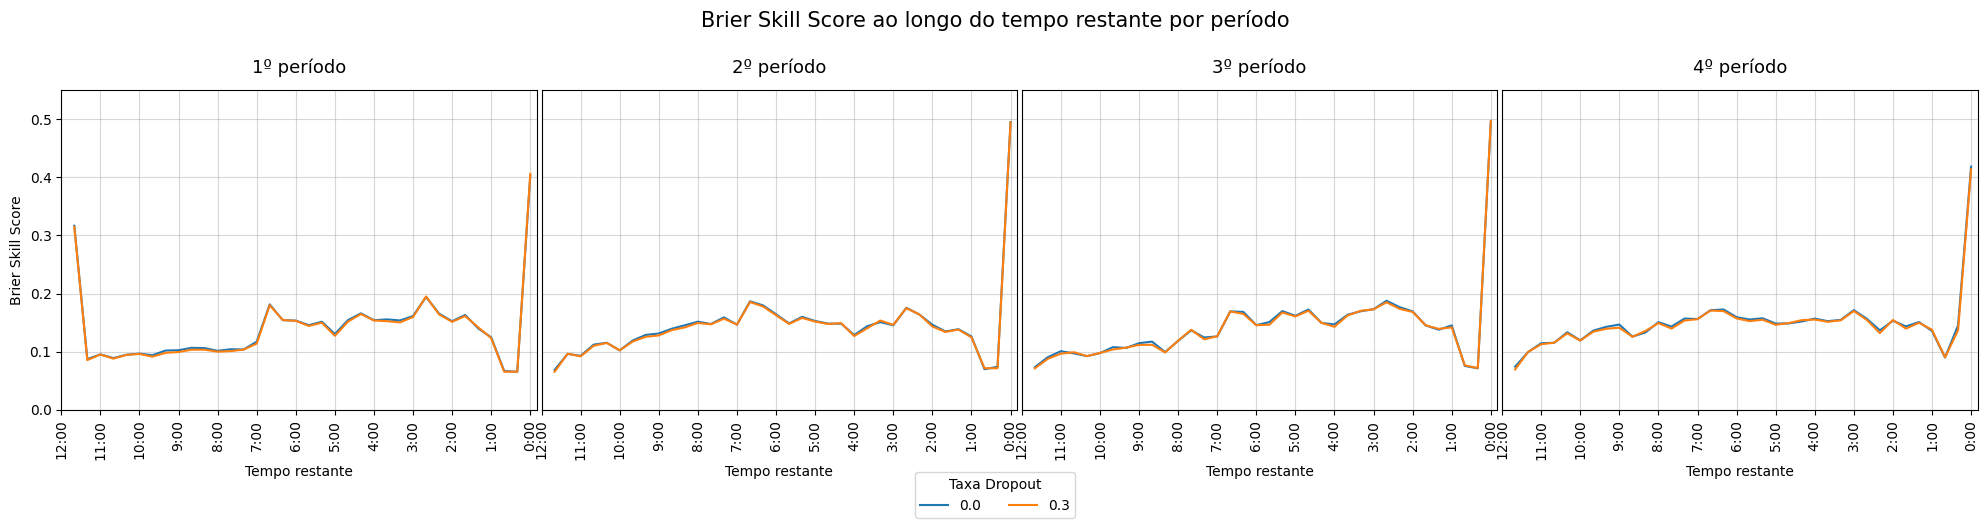

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & layer_norm == 0 & num_layers == 3 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "bss_mean")\
    .plot(ax = ax[i], legend = False)

    ax[i].set_ylim(0, 0.55)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Brier Skill Score ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

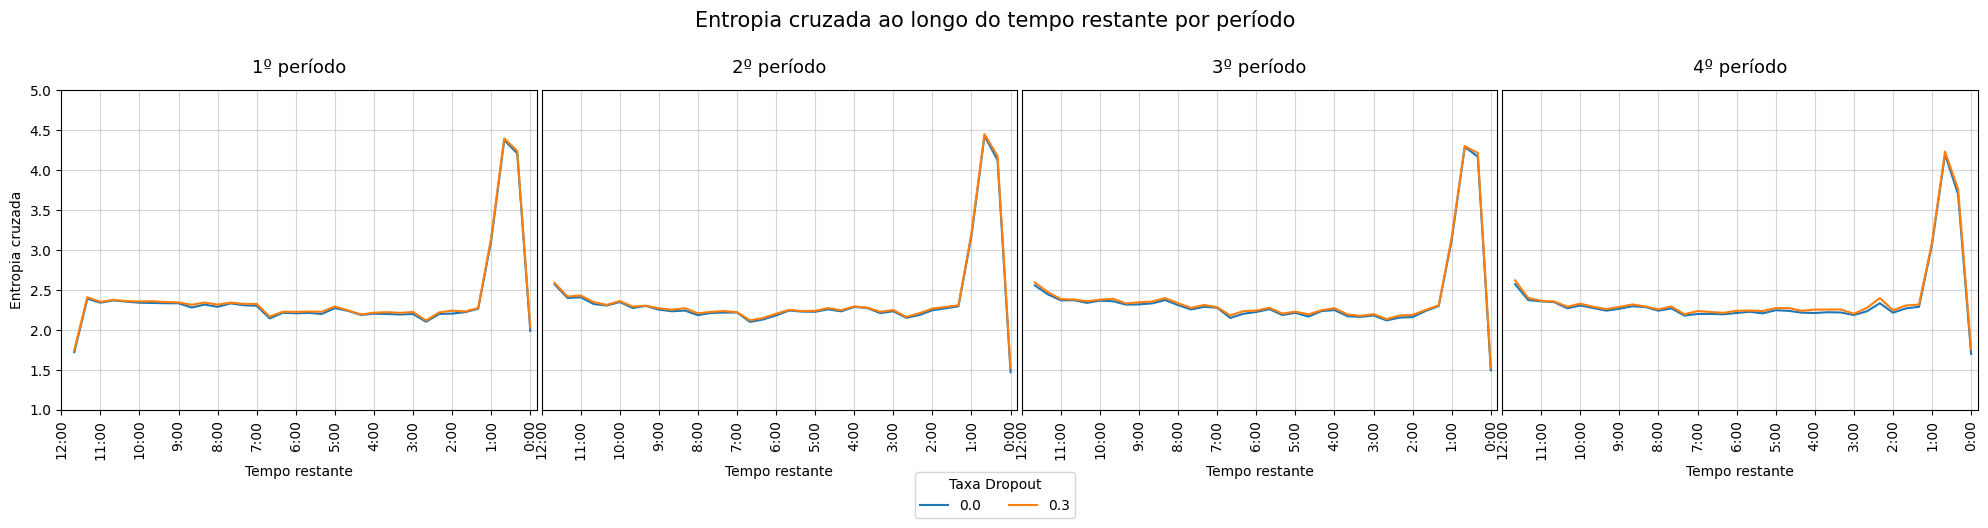

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "cross_entropy_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(1, 5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Entropia cruzada ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

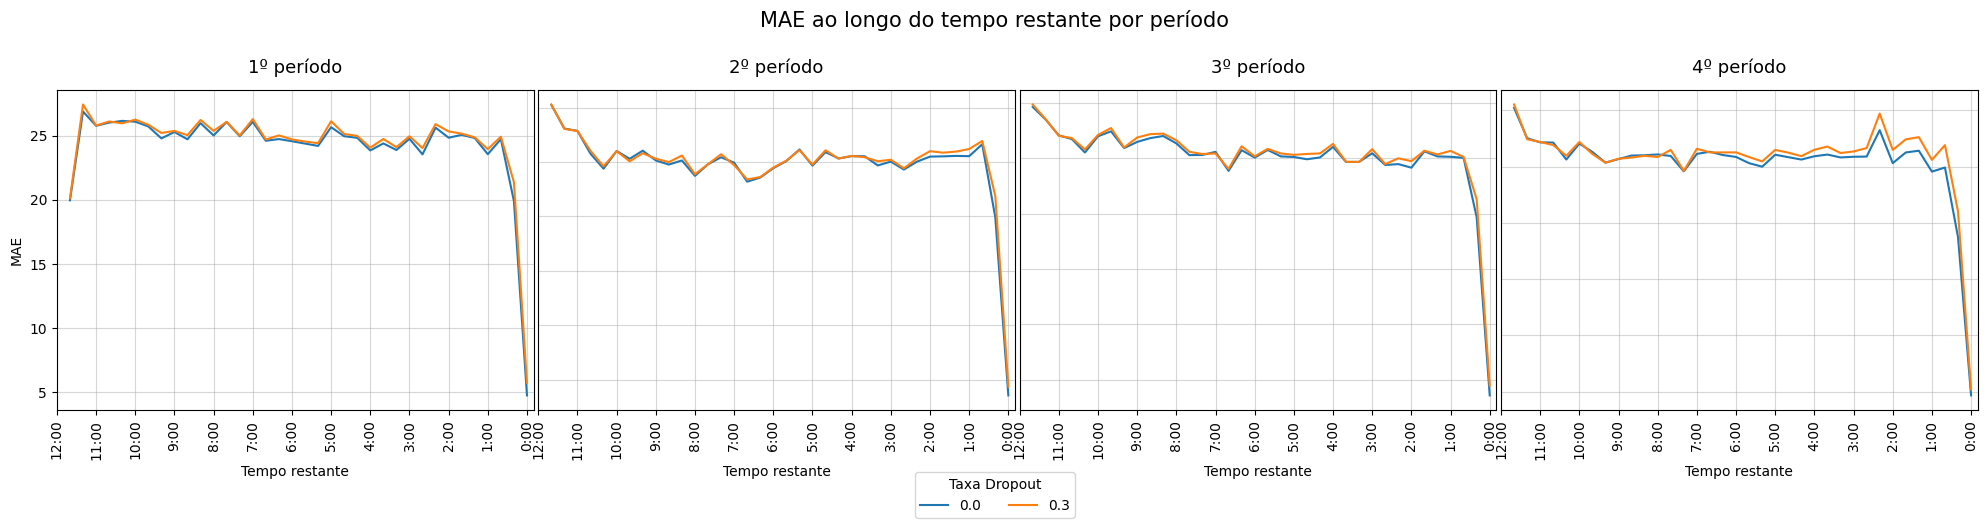

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "mae_mean")\
    .plot(ax = ax[i], legend=False)

    #ax[i].set_ylim(1, 5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("MAE")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("MAE ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

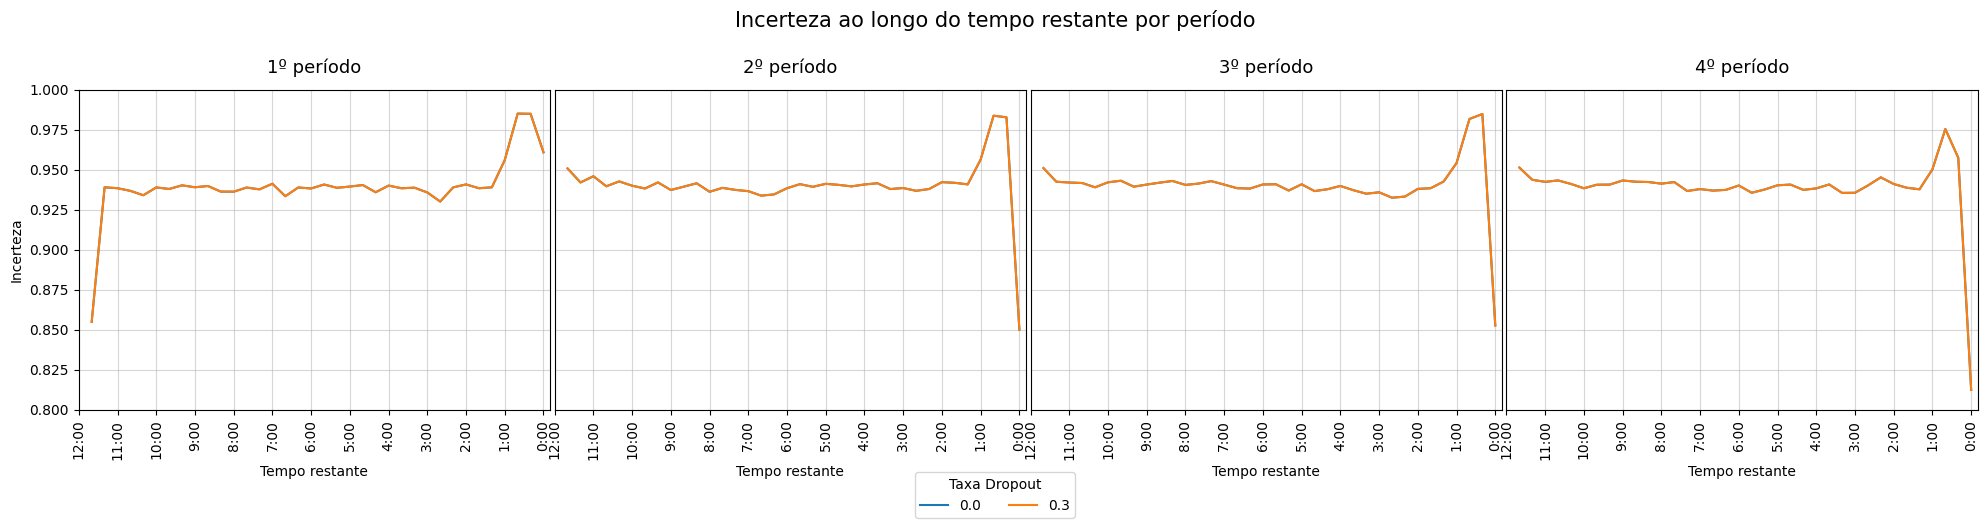

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "uncertainty_caos_mean")\
    .plot(ax = ax[i], legend = False)

    ax[i].set_ylim(0.8, 1)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Incerteza")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Incerteza ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

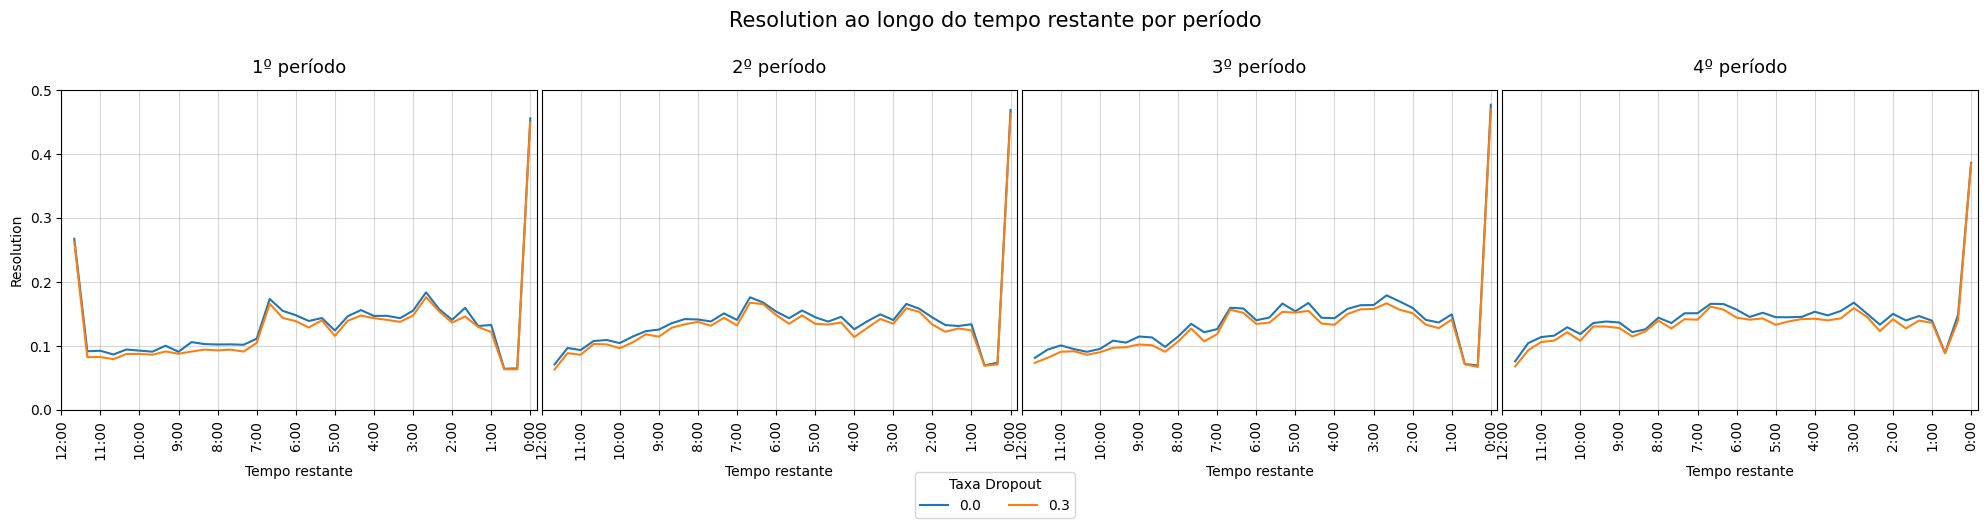

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "resolution_poder_mean")\
    .plot(ax = ax[i], legend = False)

    ax[i].set_ylim(0, 0.5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Resolution")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Resolution ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

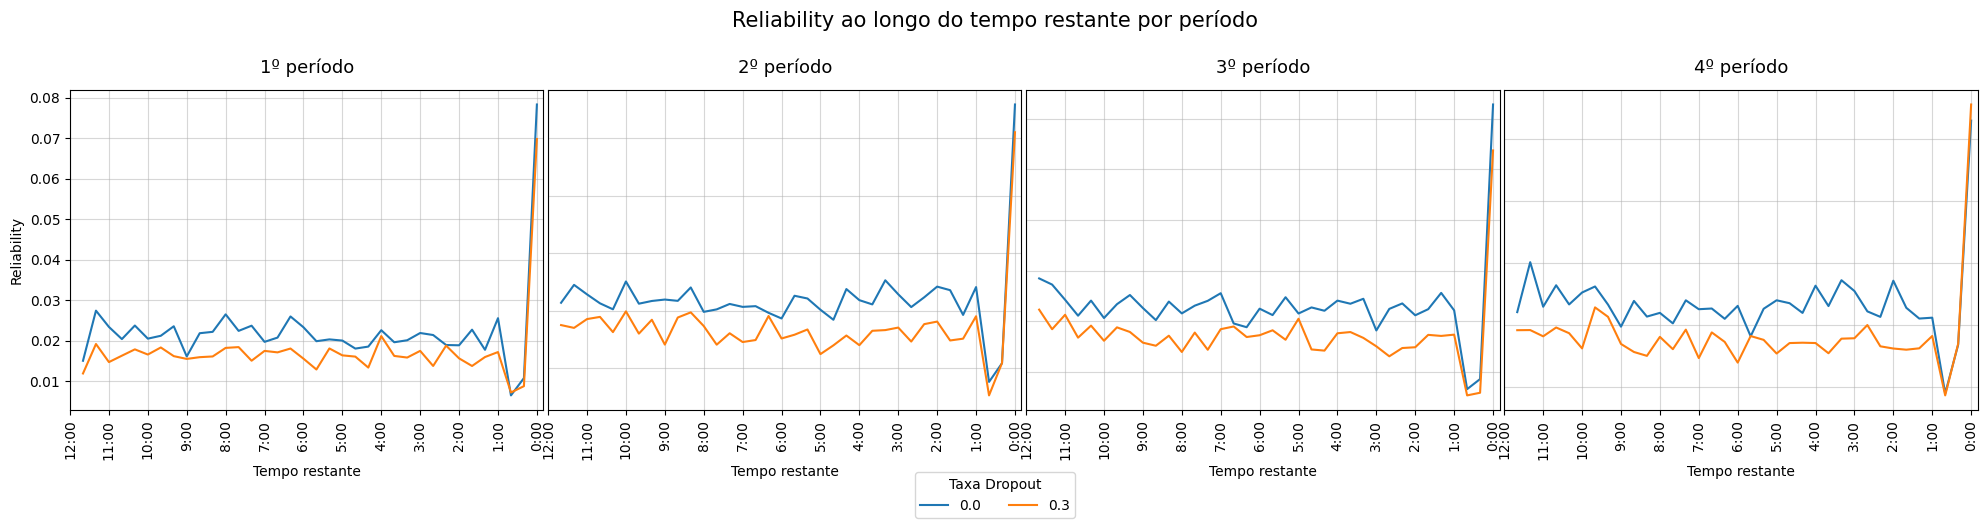

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "reliability_erro_mean")\
    .plot(ax = ax[i], legend = False)

#    ax[i].set_ylim(0, 0.5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Reliability")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Reliability ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

In [ ]:
df_resultados3.query("cat_time in ['0-200'] & period == 4")\
.pivot_table(index = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"], columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,period,cat_time,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,4,0-200,5,32,1,50,3,0.0,False,0.425648,0.428190,0.399450,0.400677,0.431386
1,4,0-200,5,32,1,50,3,0.0,True,0.392975,0.386505,0.366671,0.365862,0.387896
2,4,0-200,5,32,1,50,3,0.3,False,0.429360,0.420852,0.416342,0.392712,0.426827
3,4,0-200,5,32,1,50,3,0.3,True,0.396454,0.385716,0.372325,0.370063,0.383663
4,4,0-200,5,32,1,50,5,0.0,False,0.467995,0.441289,0.427966,0.422153,0.450973
5,4,0-200,5,32,1,50,5,0.0,True,0.394077,0.386533,0.365756,0.368818,0.393913
6,4,0-200,5,32,1,50,5,0.3,False,0.452253,0.427972,0.415548,0.401714,0.432843
7,4,0-200,5,32,1,50,5,0.3,True,0.388863,0.380799,0.372584,0.359207,0.367228
8,4,0-200,5,32,2,50,3,0.0,False,0.437690,0.424526,0.394326,0.396123,0.438561
9,4,0-200,5,32,2,50,3,0.0,True,0.392606,0.384180,0.372546,0.361030,0.383822
